# 5.1 Model Validation via IRAC Colour Space

This notebook validates the theoretical AGN models by tracking their position within the IRAC colour-colour space and comparing them against the Lacy selection wedge. Results correspond to Section 5.1 of the paper.

In [1]:
import sys
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import seaborn as sns

# Ensure the project root is in the path to import the local package
sys.path.append(os.path.abspath('..'))

from src.sed_pipeline import config, data_io, composite_math, photometry, visualization, analysis

# Styling for publication (paper ready)
plt.style.use('default')
sns.set_context("paper", font_scale=1.5)
os.makedirs(config.PROCESSED_DATA_DIR, exist_ok=True)

## 1. Load Configurations and Base Models

Loading the filters, AGN SKIRTOR models, and GALSEDATLAS templates.

In [2]:
# Load Filters
filters = photometry.load_passbands(config.FILTER_PATHS)

# Set specific paths for templates
skirtor_dir = os.path.join(config.RAW_DATA_DIR, 'Templates', 'Skirtor')
brown_dir = os.path.join(config.RAW_DATA_DIR, 'Templates', 'Brown', '2014', 'Rest')

# Load AGN Models
agn_type1 = data_io.read_skirtor_model(skirtor_dir, **config.SKIRTOR_TYPE1_PARAMS)
agn_type2 = data_io.read_skirtor_model(skirtor_dir, **config.SKIRTOR_TYPE2_PARAMS)

# Load GALSEDATLAS (Brown) Templates
brown_templates, brown_names = data_io.read_brown_galaxy_templates(brown_dir)

## 2. Generate Composite SEDs and Calculate IRAC Colours

Iterating over the alpha values to calculate composite SEDs for all templates.

In [3]:
results = []
alphas = config.ALPHA_VALUES
z_irac = 0.0 # Restframe for standard Lacy wedge demo

for t_idx, gal_sed in enumerate(brown_templates):
    gal_name = brown_names[t_idx]
    print(f"Processing template {t_idx+1}/{len(brown_templates)}: {gal_name}", end='\r')
    for agn_name, agn_model in [('Type1', agn_type1), ('Type2', agn_type2)]:
        for alpha in alphas:
            comp_sed = composite_math.create_composite_sed(agn_model, gal_sed, alpha)
            f5836, f8045 = photometry.calculate_irac_colours(comp_sed, filters['3.6'], filters['4.5'], filters['5.8'], filters['8.0'], redshift=z_irac)
            
            results.append({
                'Template': gal_name,
                'AGN_Type': agn_name,
                'Alpha': alpha,
                'f5836': f5836,
                'f8045': f8045
            })
df_results = pd.DataFrame(results)
print("\nProcessed all composite combinations.")

Processing template 128/128: UM_461150_SE14
Processed all composite combinations.


## 3. Colour Evolution Plots (Fig 1 and 2)

Plotting the IRAC colour evolution tracks. Titles are removed to make the output paper-ready.

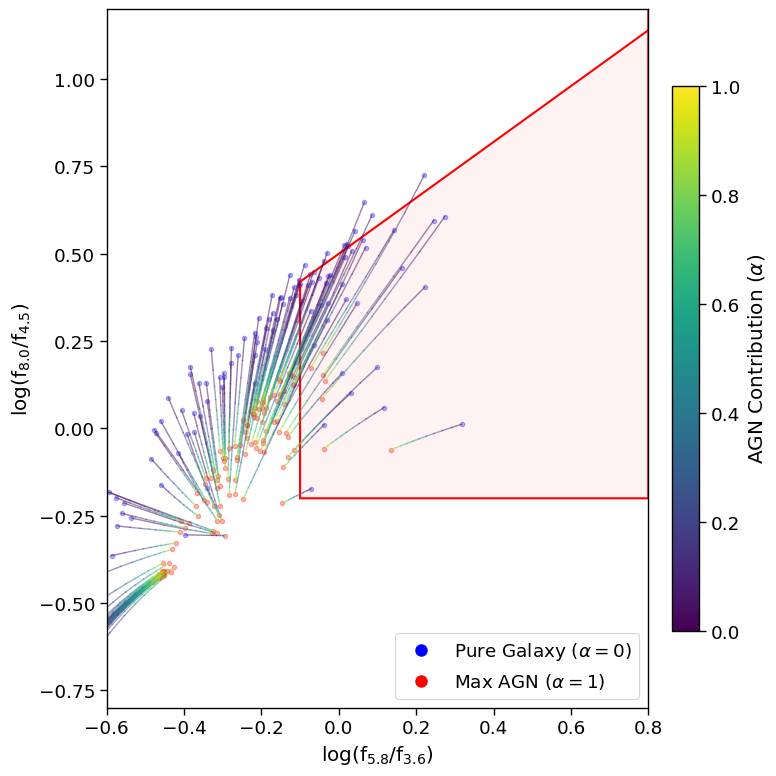

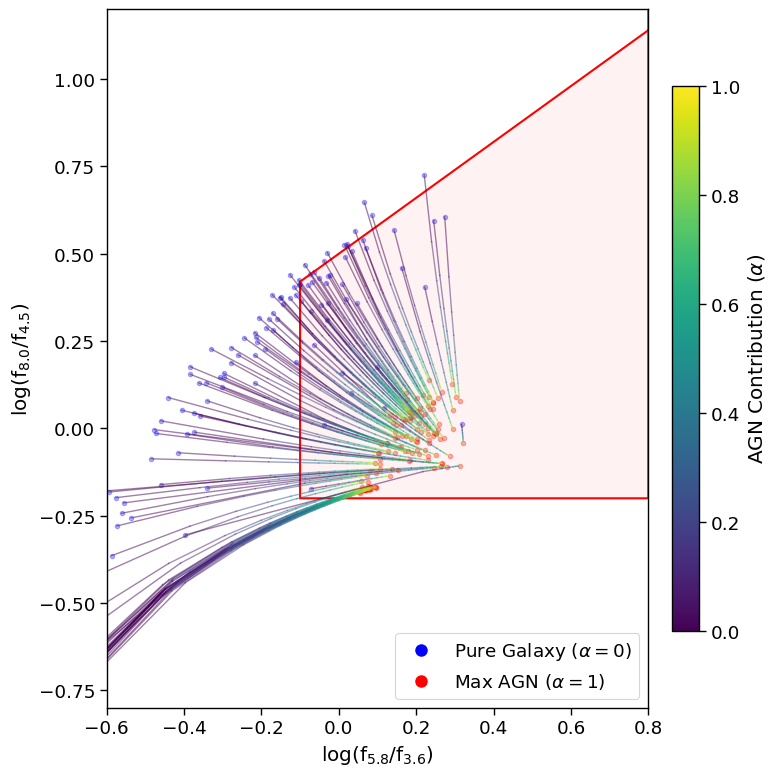

In [4]:
def plot_evolution_tracks(df, agn_type, x_col, y_col, plot_func, output_name):
    fig, ax = plt.subplots(figsize=(8, 8))
    subset = df[df['AGN_Type'] == agn_type]
    cmap = plt.cm.viridis
    for template in subset['Template'].unique():
        temp_df = subset[subset['Template'] == template].sort_values('Alpha')
        for i in range(len(temp_df)-1):
            alpha_val = temp_df['Alpha'].iloc[i]
            ax.plot(temp_df[x_col].iloc[i:i+2], temp_df[y_col].iloc[i:i+2], 
                    color=cmap(alpha_val), alpha=0.5, linewidth=1)
        ax.scatter(temp_df[x_col].iloc[0], temp_df[y_col].iloc[0], color='blue', s=10, alpha=0.3)
        ax.scatter(temp_df[x_col].iloc[-1], temp_df[y_col].iloc[-1], color='red', s=10, alpha=0.3)
    
    # Apply formatting with no title
    plot_func([], [], ax=ax, title="")
    
    custom_lines = [Line2D([0], [0], marker='o', color='w', markerfacecolor='blue', markersize=10, label=r'Pure Galaxy ($\alpha=0$)'),
                    Line2D([0], [0], marker='o', color='w', markerfacecolor='red', markersize=10, label=r'Max AGN ($\alpha=1$)')]
    ax.legend(handles=custom_lines, loc='lower right')
    
    sm = plt.cm.ScalarMappable(cmap=cmap, norm=plt.Normalize(vmin=0, vmax=1))
    cbar = fig.colorbar(sm, ax=ax, fraction=0.046, pad=0.04)
    cbar.set_label(r'AGN Contribution ($\alpha$)')
    
    plt.tight_layout()
    fig.savefig(os.path.join(config.PROCESSED_DATA_DIR, output_name), bbox_inches='tight')
    return fig, ax

plot_evolution_tracks(df_results, 'Type1', 'f5836', 'f8045', visualization.plot_irac_diagram, 'IRAC_evolution_Type1AGN_Brown.pdf')
plot_evolution_tracks(df_results, 'Type2', 'f5836', 'f8045', visualization.plot_irac_diagram, 'IRAC_evolution_Type2AGN_Brown.pdf')
plt.show()

## 4. Mean Vector Offset Analysis (Table 2)

Calculating the mean vector displacement for IRAC composites and generating a LaTeX table.

In [5]:
def calculate_irac_offsets(df, agn_type):
    subset = df[df['AGN_Type'] == agn_type]
    offsets = []
    for alpha in subset['Alpha'].unique():
        alpha_df = subset[subset['Alpha'] == alpha]
        initial_df = subset[subset['Alpha'] == 0.0]
        
        x_alpha = alpha_df['f5836'].values
        y_alpha = alpha_df['f8045'].values
        x_init = initial_df['f5836'].values
        y_init = initial_df['f8045'].values
        
        mean_offset = analysis.calculate_mean_vector_offset(x_alpha, y_alpha, x_init, y_init)
        offsets.append({'Alpha': alpha, 'Mean_Offset': mean_offset})
    return pd.DataFrame(offsets)

off1 = calculate_irac_offsets(df_results, 'Type1')
off2 = calculate_irac_offsets(df_results, 'Type2')

table_df = pd.DataFrame({
    r'AGN Contribution (\%)': [int(a*100) for a in alphas],
    'Type 1 Composite': off1['Mean_Offset'].round(2),
    'Type 2 Composite': off2['Mean_Offset'].round(2)
})

display(table_df)
table_df.to_csv(os.path.join(config.PROCESSED_DATA_DIR, 'IRAC_vectoroffset.csv'), index=False)
latex_table = table_df.to_latex(index=False, caption=r"Mean vector offset from the initial position for both AGN Composite Model Types and AGN Contribution amounts for IRAC composites.", label="tab:irac_vectoroffset")
with open(os.path.join(config.PROCESSED_DATA_DIR, 'IRAC_vectoroffset.tex'), 'w') as f:
    f.write(latex_table)

print("Exported IRAC Vector Offset table.")

,AGN Contribution (\%),Type 1 Composite,Type 2 Composite
0,0,0.00,0.00
1,10,0.09,0.23
2,20,0.15,0.34
3,30,0.19,0.41
4,40,0.23,0.46
5,50,0.26,0.50
6,60,0.29,0.53
7,70,0.31,0.56
8,80,0.33,0.57
9,90,0.34,0.59


ImportError: `Import Jinja2` failed. DataFrame.style requires jinja2. Use pip or conda to install the Jinja2 package.